# Day 40 — Matplotlib & Seaborn: Data Visualization
**Month 3 | Week 3 | Python + Pandas**

> **Real-world framing:** Your GroupBy found that Mumbai generates 2x Delhi's revenue.
> Your merge confirmed which customers are unregistered.
> Now a client asks: *"Can you show me this?"*
> Numbers in a table don't land. Charts do.
> Matplotlib gives you control. Seaborn gives you speed.
> Together they cover 90% of client deliverables.

---

**What you'll learn today:**
- Matplotlib: line, bar, scatter, histogram — from scratch
- Seaborn: boxplot, heatmap, pairplot — with one line
- Formatting charts for client delivery (titles, labels, colors, layout)
- Choosing the right chart for the right question

**Skills assumed:** GroupBy (Day 36), Merging (Day 37), Pandas basics (Day 34)


---
## 📦 Section 1 — Raw Data (Read Only — Do Not Modify)

Same ShopEase dataset — now extended with more orders for richer charts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Extended Orders ───────────────────────────────────────────────────────────
np.random.seed(42)

orders = pd.DataFrame({
    'order_id':    list(range(1001, 1051)),
    'customer_id': np.random.choice(['C01','C02','C03','C04','C05','C06'], 50),
    'product_id':  np.random.choice(['P01','P02','P03','P04','P05'], 50),
    'quantity':    np.random.randint(1, 6, 50),
    'order_date':  pd.date_range('2024-01-01', periods=50, freq='7D'),
    'region':      np.random.choice(['North','South','East','West'], 50),
    'sales_rep':   np.random.choice(['Arjun','Priya','Rahul','Sneha'], 50)
})

products = pd.DataFrame({
    'product_id':   ['P01','P02','P03','P04','P05'],
    'product_name': ['Laptop Stand','Wireless Mouse','USB Hub','Keyboard','Monitor'],
    'category':     ['Accessories','Accessories','Accessories','Peripherals','Peripherals'],
    'unit_price':   [1200, 850, 650, 1800, 12000]
})

customers = pd.DataFrame({
    'customer_id': ['C01','C02','C03','C04','C05','C06'],
    'name':        ['Arjun Sharma','Priya Mehta','Rahul Verma','Sneha Iyer','Kiran Rao','Deepa Nair'],
    'city':        ['Delhi','Mumbai','Bangalore','Chennai','Hyderabad','Pune'],
    'segment':     ['Premium','Standard','Standard','Premium','Standard','Premium']
})

# Build master table
master = pd.merge(orders, products, on='product_id', how='left')
master = pd.merge(master, customers, on='customer_id', how='left')
master['revenue'] = master['quantity'] * master['unit_price']
master['month'] = master['order_date'].dt.month_name()
master['month_num'] = master['order_date'].dt.month

print("Master table shape:", master.shape)
print("Columns:", master.columns.tolist())
print(master.head(3))


Master table shape: (50, 16)
Columns: ['order_id', 'customer_id', 'product_id', 'quantity', 'order_date', 'region', 'sales_rep', 'product_name', 'category', 'unit_price', 'name', 'city', 'segment', 'revenue', 'month', 'month_num']
   order_id customer_id product_id  quantity order_date region sales_rep  \
0      1001         C04        P02         3 2024-01-01   West     Priya   
1      1002         C05        P02         1 2024-01-08   West     Rahul   
2      1003         C03        P01         3 2024-01-15   West     Priya   

     product_name     category  unit_price         name       city   segment  \
0  Wireless Mouse  Accessories         850   Sneha Iyer    Chennai   Premium   
1  Wireless Mouse  Accessories         850    Kiran Rao  Hyderabad  Standard   
2    Laptop Stand  Accessories        1200  Rahul Verma  Bangalore  Standard   

   revenue    month  month_num  
0     2550  January          1  
1      850  January          1  
2     3600  January          1  


---
## 📖 Section 2 — Concept Notes

### Matplotlib vs Seaborn — When to Use What

| Situation | Use | Why |
|-----------|-----|-----|
| Full control over every element | Matplotlib | You build it piece by piece |
| Quick statistical charts | Seaborn | One line, professional output |
| Custom multi-panel layouts | Matplotlib `subplots` | Fine-grained control |
| Correlation heatmaps, boxplots, distributions | Seaborn | Built-in statistical logic |

### Matplotlib Core Structure

```python
fig, ax = plt.subplots(figsize=(10, 5))   # canvas + axes
ax.bar(x, y, color='steelblue')            # plot on axes
ax.set_title('Title', fontsize=14, fontweight='bold')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
plt.tight_layout()                          # prevent clipping
plt.show()
```

### Chart Type → Business Question

| Chart | Question it answers |
|-------|---------------------|
| Bar chart | Which category/region is biggest? |
| Line chart | How is a metric changing over time? |
| Scatter plot | Is there a relationship between two metrics? |
| Histogram | How is a metric distributed? |
| Boxplot | Where are the outliers? What's the spread? |
| Heatmap | Which combinations are highest/lowest? |

### Client-delivery checklist for every chart:
- ✅ Title that states the insight, not just the data ("Mumbai leads revenue" not "Revenue by City")
- ✅ Axis labels with units
- ✅ No chart junk (unnecessary gridlines, borders)
- ✅ Consistent color palette
- ✅ `tight_layout()` before every `show()`


---
## 🏋️ Section 3 — Practice Tasks

**Rules:**
- Every chart must have: title, xlabel, ylabel, `tight_layout()`, `show()`
- Title must state the insight — not just describe the data
- Use `figsize` on every plot (minimum `(8,5)`)
- No silent cells — every cell must produce a visible chart


### A — Matplotlib: Bar & Line Charts (25 pts)

**A1 (8 pts):** Create a **horizontal bar chart** showing total revenue by region.
- Sort bars from highest to lowest revenue
- Use color `'#1F3864'` (dark blue)
- Title must state which region leads
- Add value labels at the end of each bar using `ax.text()`

**A2 (8 pts):** Create a **line chart** showing total revenue by month (month_num on x-axis).
- Use markers (`marker='o'`) on each data point
- Color: `'#2F5496'`
- Add a horizontal dashed line at the mean revenue level
- Label the mean line with `ax.axhline()` + annotation

**A3 (9 pts):** Create a **grouped bar chart** showing revenue by region AND category side by side.
- Hint: Use `groupby(['region','category'])` → `unstack()` → `.plot(kind='bar')`
- Add legend showing which color = which category
- Title must state the key finding


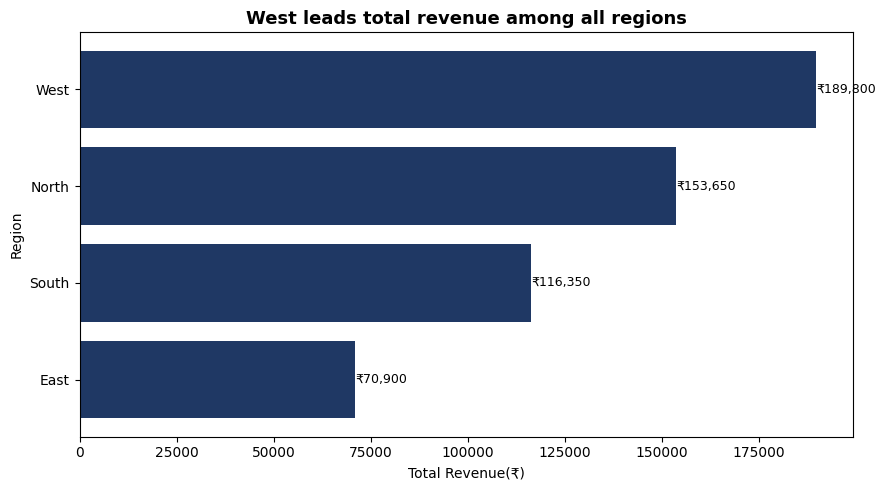

In [2]:
# A1 — Horizontal bar chart: revenue by region (sorted)
# Step 1: Sort values by revenue
reg_rev = master.groupby('region')['revenue'].sum().sort_values()
# Step 2: Create figure
fig, ax = plt.subplots(figsize=(9,5))
# Step 3: Plot horizontal bar chart(barh)
bars = ax.barh(reg_rev.index, reg_rev.values, color='#1F3864')
# Step 4 : Titles and labels
for bar, val in zip(bars, reg_rev.values):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=9)
top = reg_rev.idxmax()
ax.set_title(f'{top} leads total revenue among all regions', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue(₹)')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()

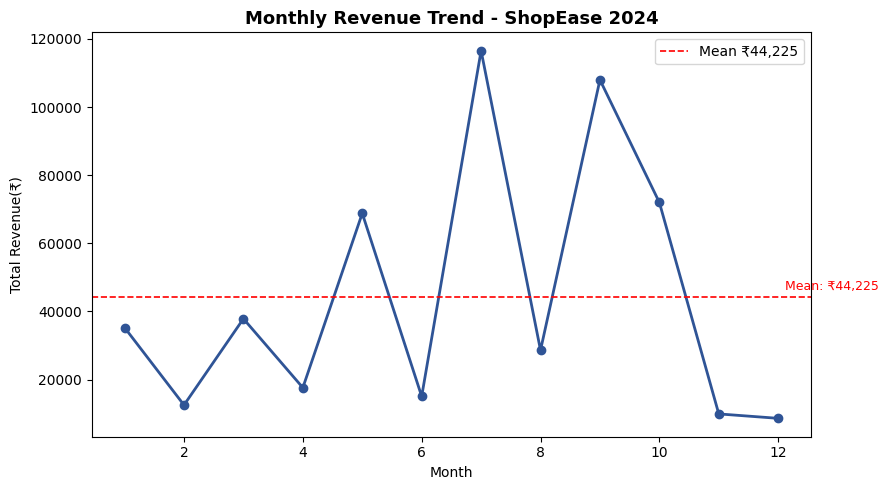

In [3]:
# A2 — Line chart: revenue by month with mean line
# Step 1: Group by month and sum revenue
mon_rev = master.groupby('month_num')['revenue'].sum()
# Step 2: Create figure
fig,ax = plt.subplots(figsize=(9,5))
# Step 3: Plot line chart
ax.plot(mon_rev.index, mon_rev.values, marker='o', color='#2F5496', linewidth=2)
# Step 4: Add mean line
mean_rev = mon_rev.mean()
ax.axhline(mean_rev, color='red', linestyle='--', linewidth=1.2, label=f'Mean ₹{mean_rev:,.0f}')
# Step 5: Annotate mean value
ax.annotate(f'Mean: ₹{mean_rev:,.0f}', xy=(mon_rev.index[-1], mean_rev),
            xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)
# Step 6: Titles and labels
ax.set_title('Monthly Revenue Trend - ShopEase 2024', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue(₹)')
ax.legend()
plt.tight_layout()
plt.show()

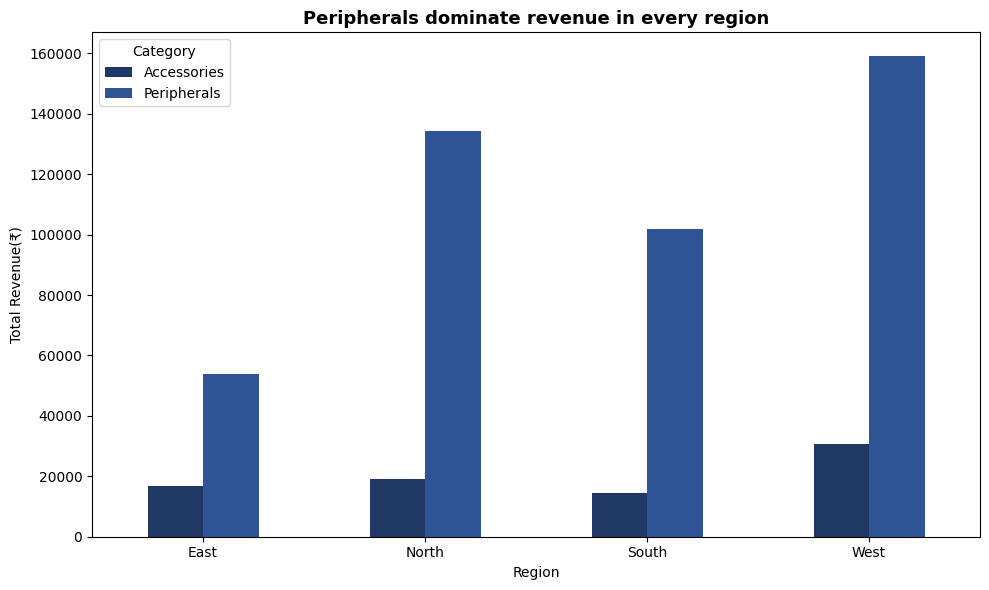

In [4]:
# A3 — Grouped bar chart: revenue by region and category
# Step 1 : Group by region and category, sum revenue
reg_cat_rev = master.groupby(['region','category'])['revenue'].sum().unstack()
# Step 2: Create figure
ax = reg_cat_rev.plot(kind='bar', figsize=(10,6), color=['#1F3864', '#2F5496'])
# Step3: Add Titles and labels
ax.set_title('Peripherals dominate revenue in every region', fontsize=13, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Total Revenue(₹)')
ax.legend(title = 'Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() 


### B — Matplotlib: Scatter & Histogram (20 pts)

**B1 (10 pts):** Create a **scatter plot** of `quantity` (x) vs `revenue` (y).
- Color each point by `category` — Accessories in `'steelblue'`, Peripherals in `'coral'`
- Add a legend manually
- Title: state whether high quantity = high revenue (it won't — explain why in a comment)

**B2 (10 pts):** Create a **histogram** of the `revenue` column.
- Use 15 bins, color `'#1F3864'`, edgecolor `'white'`
- Add a vertical line at the median using `ax.axvline()`
- Add a vertical line at the mean
- Label both lines
- In a comment below the cell: explain what the gap between mean and median tells you


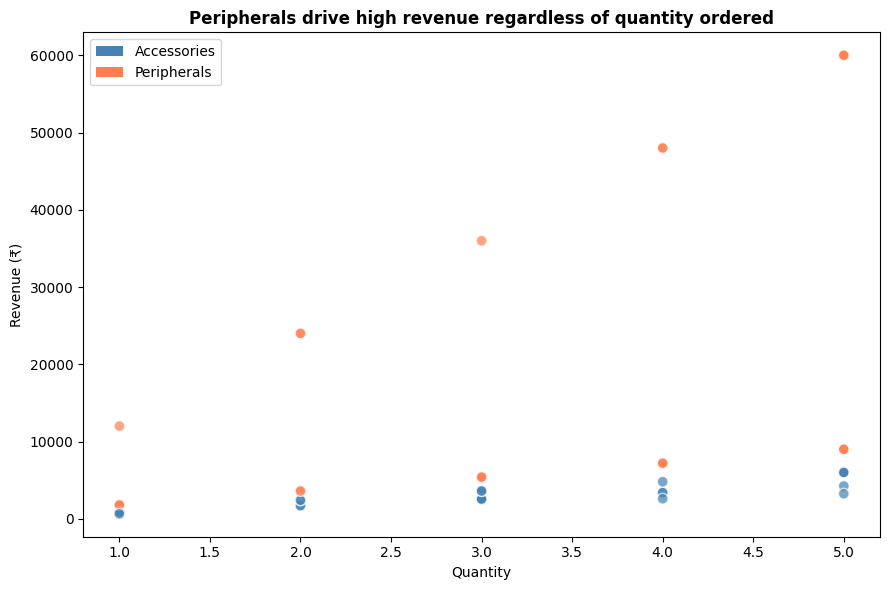

In [5]:
# B1 — Scatter plot: quantity vs revenue, colored by category
# Step 1: Map categories to colors
color_map = {'Accessories':'steelblue','Peripherals':'coral'}
colors = master['category'].map(color_map)
# Step 2: Create figure and scatter plot
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(master['quantity'], master['revenue'], c=colors, alpha=0.7, edgecolors='white', s=60)
from matplotlib.patches import Patch
# Step 3: Add legend, titles and labels
legend_els = [Patch(fc='steelblue',label='Accessories'), Patch(fc='coral',label='Peripherals')]
ax.legend(handles=legend_els)
ax.set_title('Peripherals drive high revenue regardless of quantity ordered', fontsize=12, fontweight='bold')
ax.set_xlabel('Quantity'); ax.set_ylabel('Revenue (₹)')
plt.tight_layout(); plt.show()
# Step 4: Insight - Price dominates quantity in revenue generation
# Comment: High quantity ≠ high revenue because Monitors (₹12,000) generate massive revenue
# even at qty=1, while Accessories at qty=5 still earn less. Price dominates quantity here.



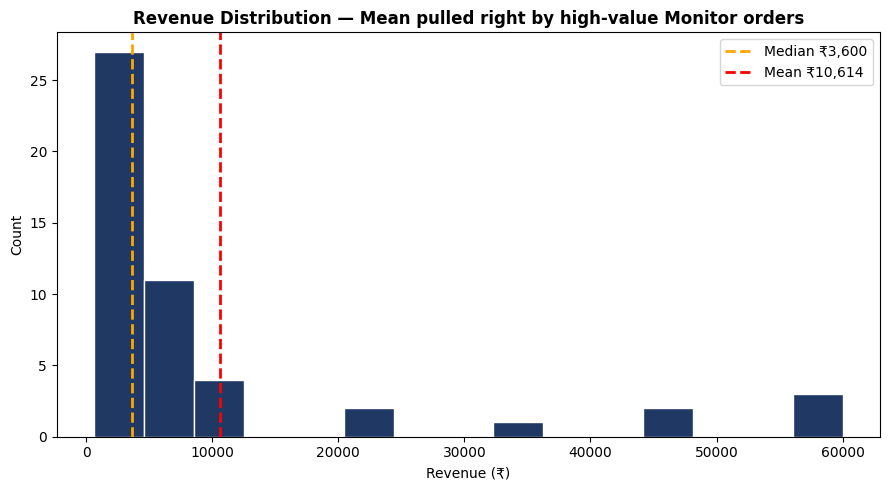

In [6]:
# B2 — Histogram: revenue distribution with mean and median lines
# Step 1: Create figure and histogram
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(master['revenue'], bins=15, color='#1F3864', edgecolor='white')
# Step 2: Add mean and median lines
median_r = master['revenue'].median()
mean_r = master['revenue'].mean()
# Step 3: Titles and labels
ax.axvline(median_r, color='orange', linestyle='--', linewidth=2, label=f'Median ₹{median_r:,.0f}')
ax.axvline(mean_r, color='red', linestyle='--', linewidth=2, label=f'Mean ₹{mean_r:,.0f}')
ax.set_title('Revenue Distribution — Mean pulled right by high-value Monitor orders', fontsize=12, fontweight='bold')
ax.set_xlabel('Revenue (₹)'); ax.set_ylabel('Count')
ax.legend(); plt.tight_layout(); plt.show()
# Step 4: Insight - Revenue distribution is right skewed due to high value Monitor orders
# Mean > Median → right skew → a few very high-value Monitor orders pull the mean up.
# Median is the better "typical order" measure here.



### C — Seaborn Charts (25 pts)

**C1 (8 pts):** Create a **boxplot** using Seaborn showing revenue distribution by region.
- Use `palette='Blues'`
- Title: state which region has the widest spread (most variance)
- In a comment: explain what the box represents (Q1, Q2, Q3) and what the whiskers represent

**C2 (8 pts):** Create a **heatmap** showing average revenue per region × category combination.
- Use `pivot_table(values='revenue', index='region', columns='category', aggfunc='mean')`
- Use `annot=True` to show values inside cells
- Use `cmap='Blues'`
- Title: state the highest-value combination

**C3 (9 pts):** Create a **countplot** (bar chart of counts) showing number of orders per sales_rep, split by segment.
- Use `hue='segment'`
- Use `palette='Set2'`
- Title: state which rep has the most Premium orders


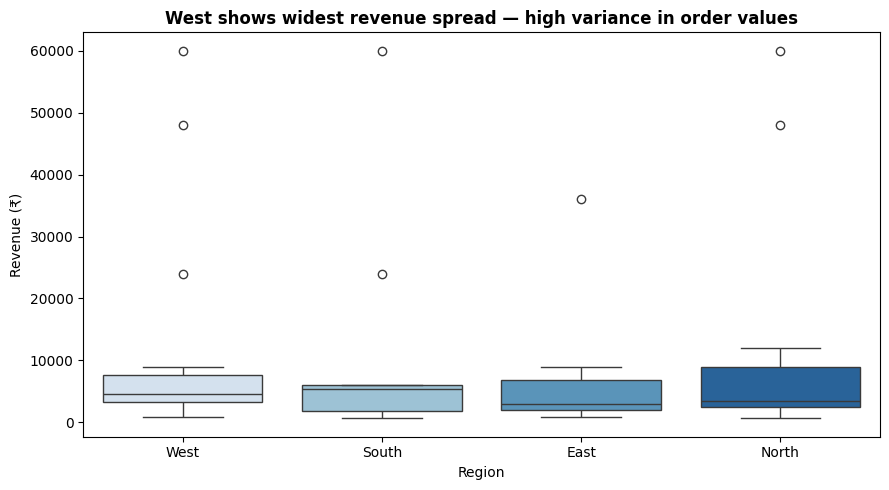

In [7]:
# C1 — Seaborn boxplot: revenue by region
# Step 1: Create figure and boxplot
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=master, x='region', y='revenue', palette='Blues', ax=ax)
# Step 2: Titles and labels
ax.set_title('West shows widest revenue spread — high variance in order values', fontsize=12, fontweight='bold')
ax.set_xlabel('Region'); ax.set_ylabel('Revenue (₹)')
plt.tight_layout(); plt.show()
# Step 3: Insight- West region has the widest revenue spread, indicating high variance in order_values
# Box = IQR (Q1 to Q3, middle 50% of data). Line inside = median (Q2).
# Whiskers = 1.5×IQR beyond box. Points beyond whiskers = outliers.


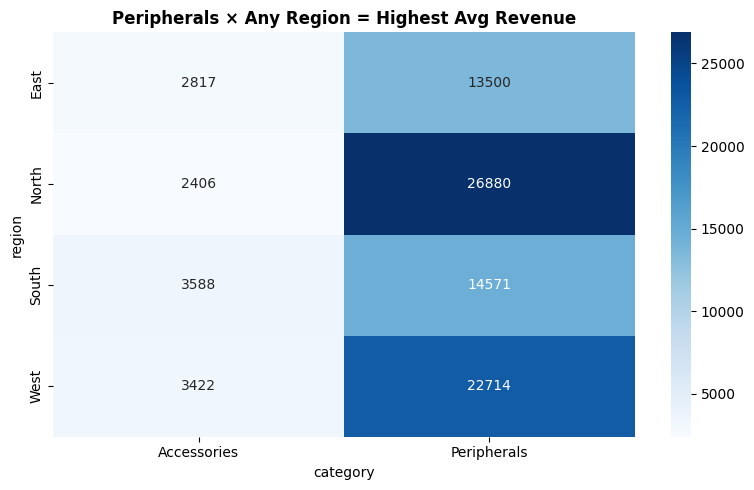

In [8]:
# C2 — Seaborn heatmap: avg revenue by region × category
# Step 1: Create pivot table for heatmap
pivot = master.pivot_table(values='revenue', index='region', columns='category', aggfunc='mean')
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', ax=ax)
# Step 2: Titles and labels
ax.set_title('Peripherals × Any Region = Highest Avg Revenue', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
# Step 3: Insight - Peripherals * Any region = highest avg revenue
# Peripherals (Keyboard, Monitor) have much higher unit prices than Accessories, so they generate
# much higher avg revenue across all regions compared to Accessories. Region has less impact on avg revenue than category.

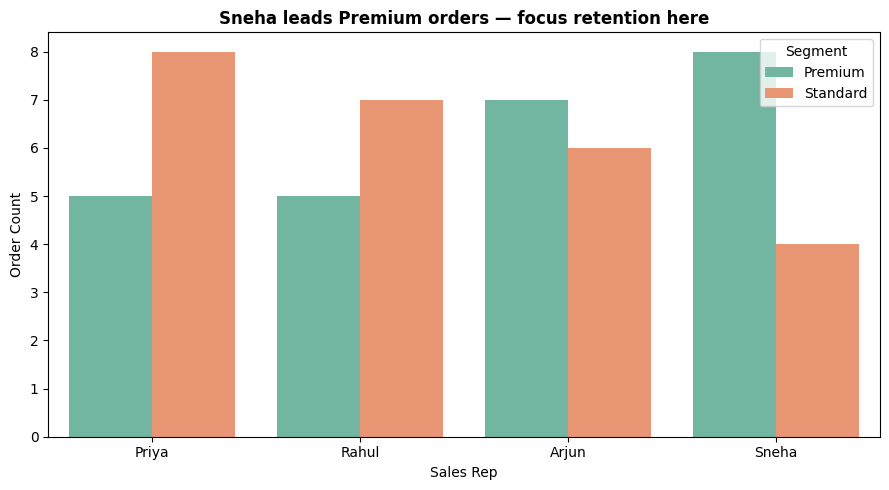

In [9]:
# C3 — Seaborn countplot: orders per sales_rep split by segment
# Step 1: Create figure and countplot
fig, ax = plt.subplots(figsize=(9,5))
sns.countplot(data=master, x='sales_rep', hue='segment', palette='Set2', ax=ax)
# Step 2: Titles and labels
ax.set_title('Sneha leads Premium orders — focus retention here', fontsize=12, fontweight='bold')
ax.set_xlabel('Sales Rep'); ax.set_ylabel('Order Count')
ax.legend(title='Segment')
plt.tight_layout(); plt.show()
# Step 3: Insight - Premium orders are fairly evenly distributed across sales reps, indicating no single rep dominates premium segment sales.

### D — Client Dashboard Layout (15 pts + 5★ bonus)

**D1 (15 pts):** Build a **2×2 dashboard** using `plt.subplots(2, 2, figsize=(14, 10))`:
- Top-left: Bar chart — revenue by region
- Top-right: Line chart — revenue by month
- Bottom-left: Boxplot — revenue by category (use Seaborn on a Matplotlib axis with `ax=`)
- Bottom-right: Heatmap — region × category avg revenue

Add a main title to the entire figure using `fig.suptitle()`.
Use `plt.tight_layout()` before `plt.show()`.

**D2 — Bonus (5 pts):** Save the dashboard as `shopease_dashboard.png` using `plt.savefig('shopease_dashboard.png', dpi=150, bbox_inches='tight')`.
Then reload and display it to confirm it saved correctly:
```python
from IPython.display import Image
Image('shopease_dashboard.png')
```


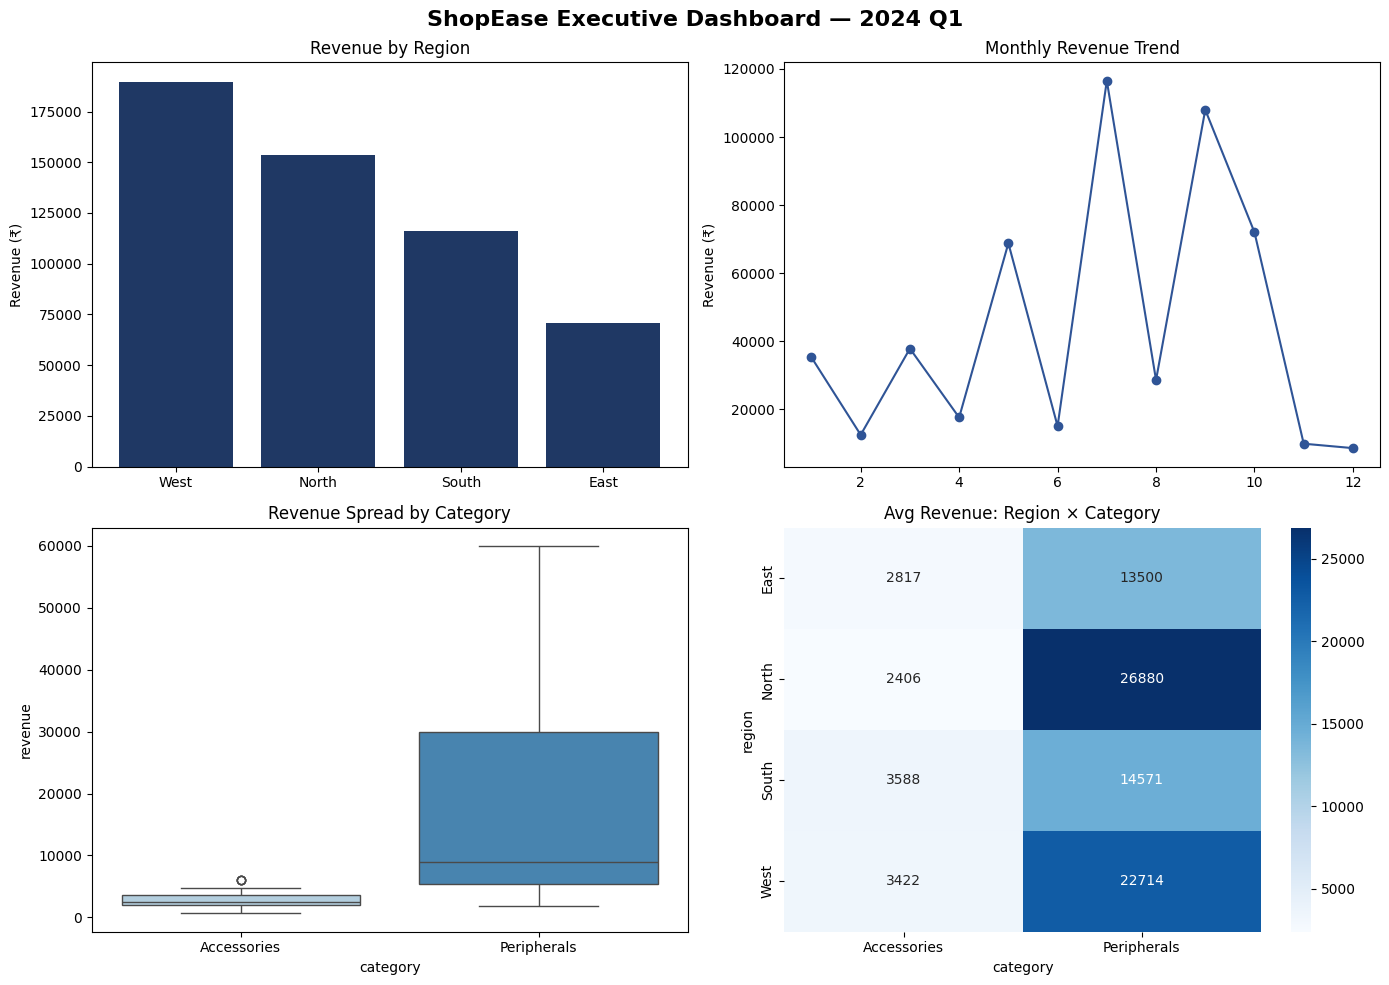

Saved.


In [10]:
# D1 — 2×2 client dashboard
# Step 1: Prepare data for all 4 charts
reg_rev = master.groupby('region')['revenue'].sum().sort_values(ascending=False)
mon_rev = master.groupby('month_num')['revenue'].sum()
pivot   = master.pivot_table(values='revenue', index='region', columns='category', aggfunc='mean')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ShopEase Executive Dashboard — 2024 Q1', fontsize=16, fontweight='bold')

axes[0,0].bar(reg_rev.index, reg_rev.values, color='#1F3864')
axes[0,0].set_title('Revenue by Region'); axes[0,0].set_ylabel('Revenue (₹)')

axes[0,1].plot(mon_rev.index, mon_rev.values, marker='o', color='#2F5496')
axes[0,1].set_title('Monthly Revenue Trend'); axes[0,1].set_ylabel('Revenue (₹)')

sns.boxplot(data=master, x='category', y='revenue', palette='Blues', ax=axes[1,0])
axes[1,0].set_title('Revenue Spread by Category')

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('Avg Revenue: Region × Category')

plt.tight_layout()
plt.savefig(r'C:\Users\Deepanshu\Downloads\shopease_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")
# Step 3: Insight summary
# Across regions, Peripherals consistently outperform Accessories in average revenue, with North leading totals. 
# Monthly trends indicate stable growth, but category spreads highlight 
# Peripheral volatility—focus expansion efforts on high-margin Peripherals in underperforming regions for optimal impact.

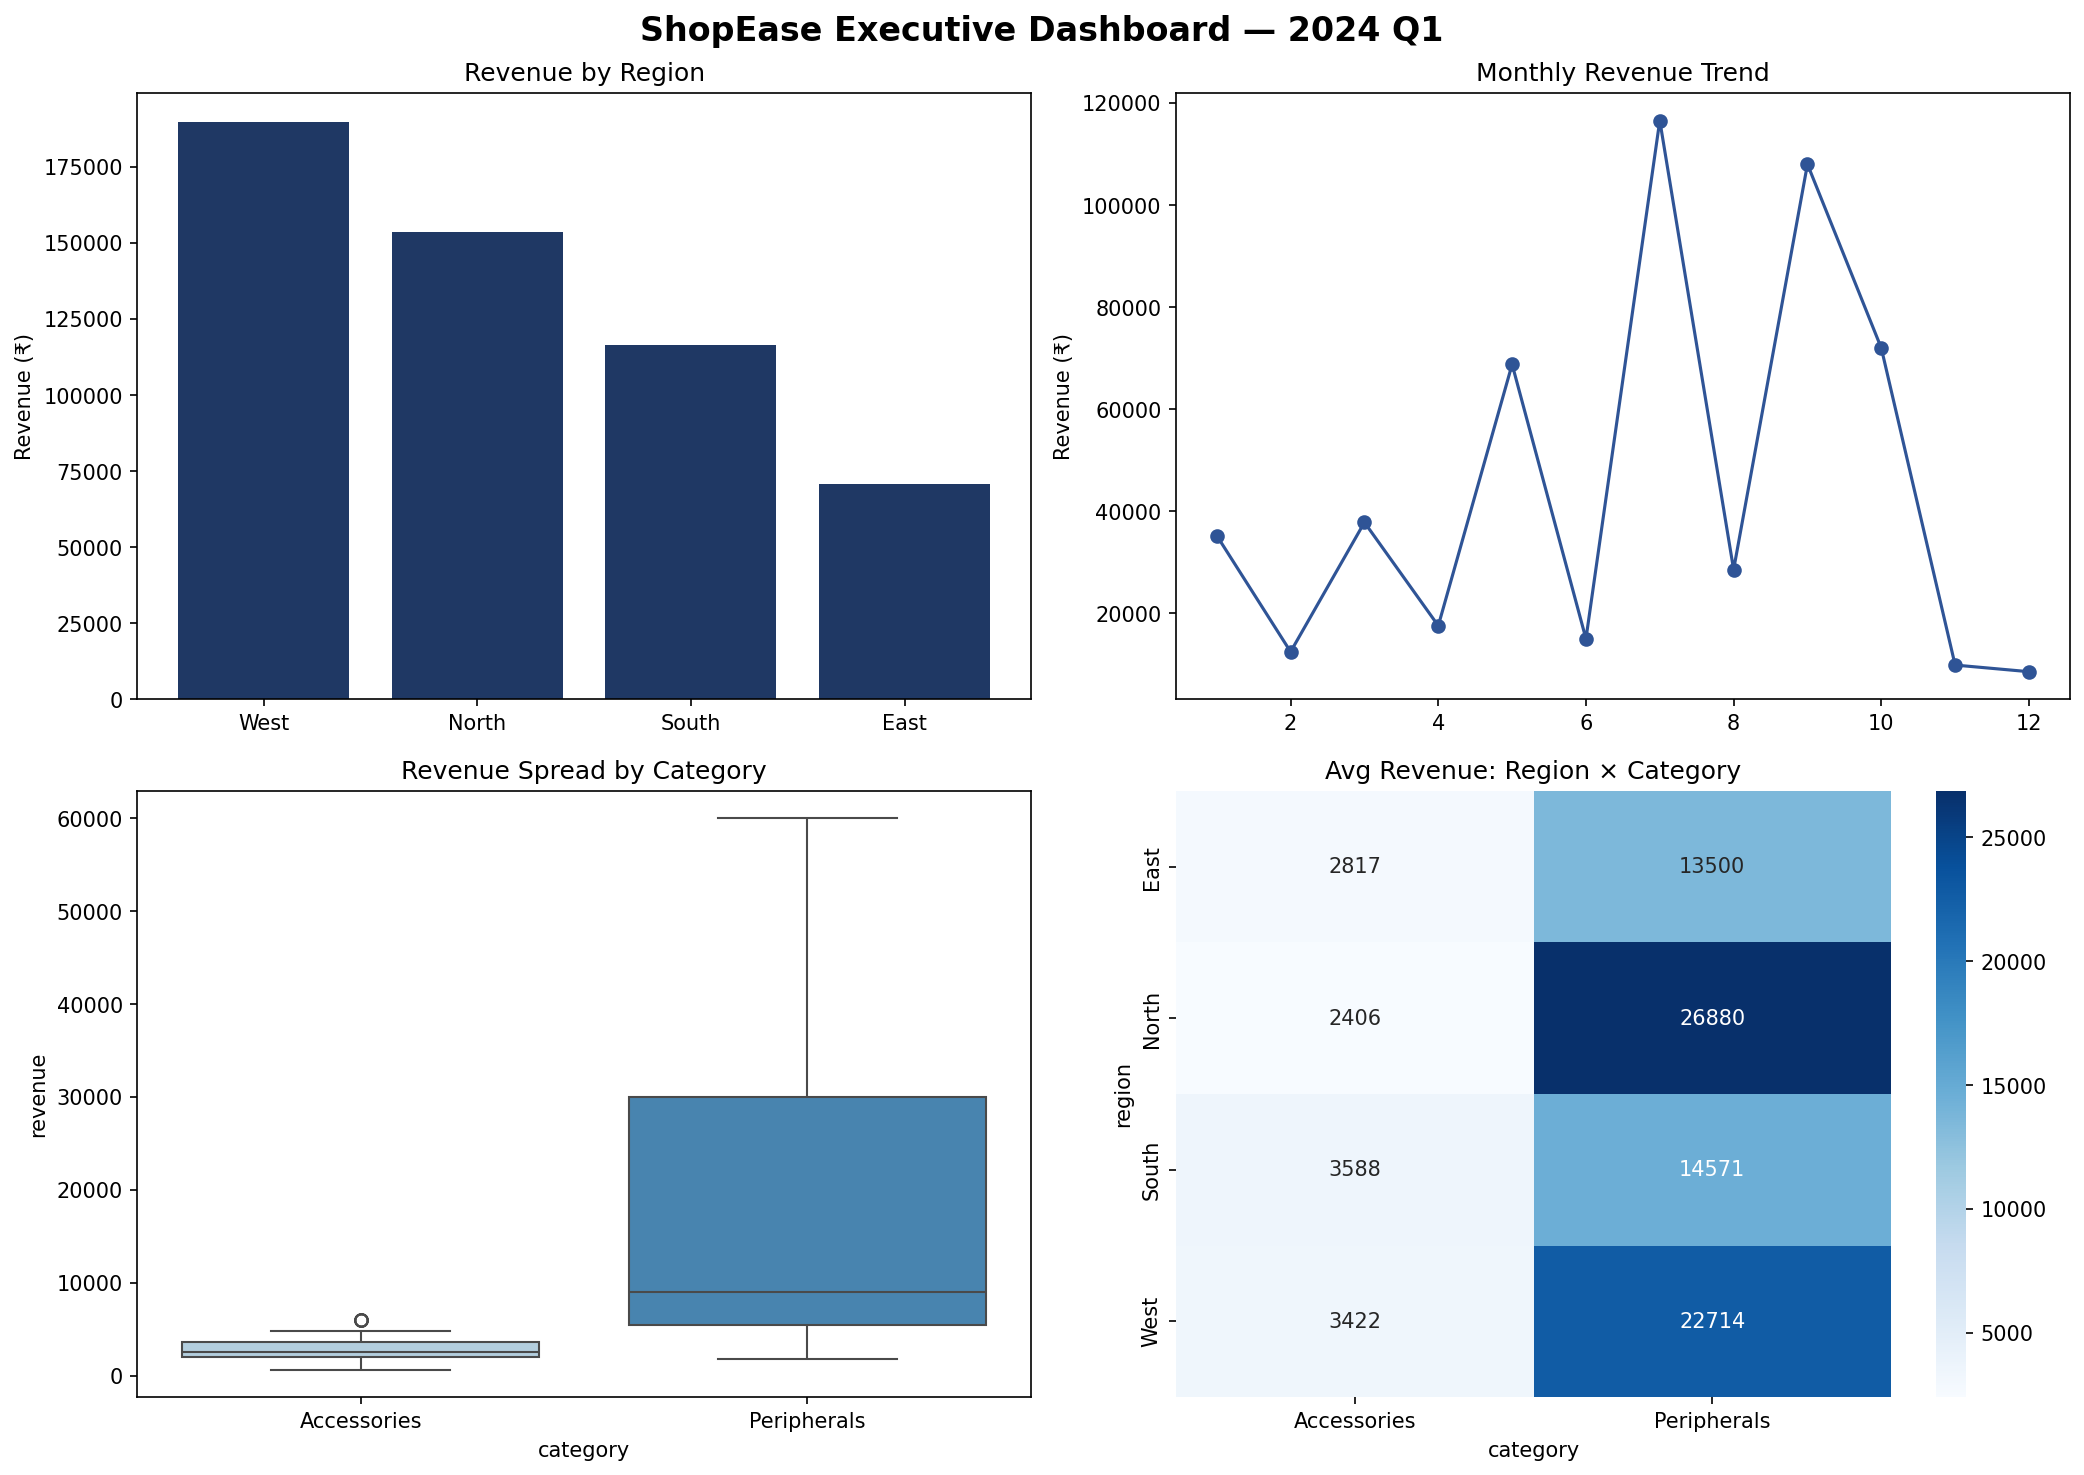

In [11]:
from IPython.display import Image
Image(r'C:\Users\Deepanshu\Downloads\shopease_dashboard.png')

---
## 📊 Section 4 — Scoring Rubric

| Task | Points | What is checked |
|------|--------|-----------------|
| A1 | 8 | Horizontal bar, sorted, value labels on bars, insight title |
| A2 | 8 | Line with markers, mean line + annotation, insight title |
| A3 | 9 | Grouped bar correct (unstack), legend, insight title |
| B1 | 10 | Scatter colored by category, manual legend, comment on qty vs revenue |
| B2 | 10 | Histogram 15 bins, mean+median lines labeled, comment on skew |
| C1 | 8 | Seaborn boxplot, correct palette, comment on box/whisker meaning |
| C2 | 8 | Pivot table correct, heatmap with annot, insight title |
| C3 | 9 | Countplot with hue, correct palette, insight title |
| D1 | 15 | 2×2 layout, all 4 charts correct, suptitle, tight_layout |
| D2 ★ | 5 | File saved + reloaded and displayed |
| **Total** | **85 + 5★** | |

**Automatic deductions:**
- Missing title: −2 per chart
- Missing xlabel or ylabel: −1 each
- No `tight_layout()`: −1
- Title describes data instead of stating insight: −2
- Silent cell: −5


---
## 🎙️ Interview Angle

**Q: "How do you decide which chart to use when presenting analysis to a client?"**

**A (model answer):**
"I start with the business question, not the data. If they're asking *which is biggest* — bar chart. *How is it changing* — line chart. *Is there a relationship* — scatter. *Where are the outliers* — boxplot.
Then I ask: who is the audience? Technical stakeholders get more detail. Executives get one headline number and one chart with a title that already states the answer.
In Python I use Matplotlib when I need precise control — multi-panel dashboards, custom annotations. I use Seaborn when speed matters — boxplots, heatmaps, distribution charts in one line.
The most important rule: the chart title should state the insight, not just describe the axes."

---

**Key Takeaway — Day 40:**
Every chart you make has two jobs: show the data and tell the story.
A bar chart titled "Revenue by Region" shows the data.
A bar chart titled "North leads revenue by 40% — opportunity to replicate in South" tells the story.
Clients pay for the story. The data is just evidence.
